In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
file = "/content/3. Parcial - medical_attention_data.xlsx"

sheets = pd.ExcelFile(file).sheet_names

dfs = []

for sheet in sheets:

    temp = pd.read_excel(file, sheet_name=sheet)

    temp["Branch"] = sheet

    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

df.head()

,PatientID,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch,Pregnancies
0,BEL-0001,167.0,44,50,135,19.375,0.788,49,0,Bello,NaN
1,BEL-0002,60.0,54,12,602,43.115,1.640,37,1,Bello,NaN
2,BEL-0003,104.0,89,13,845,21.230,1.958,35,1,Bello,NaN
3,BEL-0004,72.0,61,12,145,49.781,1.643,25,1,Bello,NaN
4,BEL-0005,68.0,75,58,529,45.160,0.471,79,1,Bello,NaN


In [49]:
numerical_cols = df.select_dtypes(include=['number'])
correlation_matrix = numerical_cols.corr()
print("Matriz de Correlación:")
print(correlation_matrix)

print("\nCorrelación de 'Diabetes' con otras variables:")
print(correlation_matrix['Diabetes'].sort_values(ascending=False))

Matriz de Correlación:
                           Glucose  BloodPressure  SkinThickness   Insulin  \
Glucose                   1.000000       0.013956      -0.006072  0.015633   
BloodPressure             0.013956       1.000000      -0.007808  0.005684   
SkinThickness            -0.006072      -0.007808       1.000000 -0.021895   
Insulin                   0.015633       0.005684      -0.021895  1.000000   
BMI                      -0.039272      -0.008646       0.025596 -0.008352   
DiabetesPedigreeFunction -0.021183      -0.011843       0.011530 -0.009968   
Age                       0.004046      -0.003388       0.007822 -0.001410   
Diabetes                 -0.000049       0.001454       0.017592 -0.001180   
Pregnancies               0.015691      -0.009923      -0.005091  0.029169   

                               BMI  DiabetesPedigreeFunction       Age  \
Glucose                  -0.039272                 -0.021183  0.004046   
BloodPressure            -0.008646              

In [28]:
variable = "BMI"

In [29]:
internos = df[df["Branch"] == "Bello"][variable]

externos = df[df["Branch"] == "Sabaneta"][variable]

LDAo = np.array(internos)
LDAe = np.array(externos)

In [30]:
stats = df.groupby("Branch")["BMI"].agg([
    "mean",
    "std"
])

stats

,mean,std
Branch,,
Bello,32.990480,9.881730
Caldas,33.063493,10.209571
Envigado,32.550485,9.827211
Itagui,32.241159,9.967073
Medellín,32.879753,9.976137
Sabaneta,32.992060,9.894817


In [31]:
us = stats.loc["Sabaneta"]["mean"]
sigmas = stats.loc["Sabaneta"]["std"]

Se calcularon las medidas de tendencia central y dispersión de la variable BMI para cada sucursal. Posteriormente se estimó la discrepancia entre las medias de cada sucursal respecto a la sucursal Sabaneta, utilizando la fórmula de discrepancia relativa.

Los resultados muestran que la sucursal con menor discrepancia respecto a Sabaneta es Bello, lo que indica que ambas bases de datos presentan características estadísticas similares. Por esta razón, Bello se selecciona como la sucursal con mayor credibilidad para la integración de los pacientes provenientes de Sabaneta.

In [32]:
for branch in stats.index:

    if branch != "Sabaneta":

        uo = stats.loc[branch]["mean"]

        sigmao = stats.loc[branch]["std"]

        D = abs((uo-us)/uo)*100

        print(branch, "Discrepancia:", D)



Bello Discrepancia: 0.004787749785258365
Caldas Discrepancia: 0.21604876499315379
Envigado Discrepancia: 1.3565841949544784
Itagui Discrepancia: 2.329011237738475
Medellín Discrepancia: 0.3415673726219442


In [33]:
sucursal_afine = "Bello"

In [34]:
internos = df[df["Branch"] == sucursal_afine]["BMI"]

externos = df[df["Branch"] == "Sabaneta"]["BMI"]

LDAo = np.array(internos)

LDAe = np.array(externos)

In [35]:
print("Número de datos internos:", len(LDAo))
print("Número de datos externos:", len(LDAe))

Número de datos internos: 502
Número de datos externos: 621


Se realizó la caracterización de los datos internos y externos mediante el cálculo de la media y la desviación estándar. Estas medidas permiten describir el comportamiento de la variable BMI en ambas bases de datos antes de realizar el proceso de integración.

**PERTENENCIA**

In [58]:
LDAint=np.array([])
LDAT=[];m=0
LDAv=np.zeros((len(LDAo),1));
umbral = 0.5
for k in range(len(LDAo)):
  VP=np.exp(-0.5*((uo-LDAo[k])/sigmao)**2)
  if VP>umbral and LDAv[k]==0:
    LDAint=np.append(LDAint,LDAo[k])
    LDAv[k]=1
    m=m+1

LDAint=np.append(LDAint,LDAe)
LDAT.append(LDAint)
uint,sigmaint, Casint, Kurint,_=caracterizacion(LDAint)

In [59]:
from scipy.stats import skew, kurtosis

def caracterizacion(data):
    mean_val = np.mean(data)
    std_val = np.std(data)
    skew_val = skew(data)
    kurt_val = kurtosis(data)

    return mean_val, std_val, skew_val, kurt_val, 0

In [36]:
uo = np.mean(LDAo)
sigmao = np.std(LDAo)

ue = np.mean(LDAe)
sigmae = np.std(LDAe)

print("Media datos internos:", uo)
print("Desviación datos internos:", sigmao)

print("Media datos externos:", ue)
print("Desviación datos externos:", sigmae)

Media datos internos: 32.99048007968127
Desviación datos internos: 9.87188262412109
Media datos externos: 32.99205958132045
Desviación datos externos: 9.88684665522277


En esta etapa se aplica el criterio de aceptación, el cual evalúa si cada dato externo presenta una mayor probabilidad de pertenecer a la distribución de los datos internos que a su propia distribución. Los datos que cumplen esta condición se integran a la base de datos interna.

In [48]:
LDAint2 = np.copy(np.array(LDAo))

for k in range(len(LDAe)):

    VPo = np.exp(-0.5*((uo-LDAe[k])/sigmao)**2)

    VPe = np.exp(-0.5*((ue-LDAe[k])/sigmae)**2)

    if VPo > VPe:

        LDAint2 = np.append(LDAint2, LDAe[k])

In [39]:
LDAint2 = np.copy(np.array(LDAo))

for k in range(len(LDAe)):

    VPo = np.exp(-0.5*((uo-LDAe[k])/sigmao)**2)

    VPe = np.exp(-0.5*((ue-LDAe[k])/sigmae)**2)

    if VPo > VPe:

        LDAint2 = np.append(LDAint2, LDAe[k])

In [50]:
print("Número de datos después de integración:", len(LDAint3))

Número de datos después de integración: 524


Posteriormente se aplica el método de aceptación y rechazo, el cual incorpora un criterio probabilístico adicional mediante la generación de números aleatorios. Este procedimiento permite integrar únicamente aquellos datos externos que cumplen simultáneamente las condiciones de similitud estadística y aceptación probabilística.

In [38]:
LDAint3 = np.copy(np.array(LDAo))

for k in range(len(LDAe)):

    VPo = np.exp(-0.5*((uo-LDAe[k])/sigmao)**2)

    VPe = np.exp(-0.5*((ue-LDAe[k])/sigmae)**2)

    aleatorio = np.random.rand()

    if VPo > VPe and VPe > aleatorio:

        LDAint3 = np.append(LDAint3, LDAe[k])

In [41]:
ui3 = np.mean(LDAint3)

sigmai3 = np.std(LDAint3)

print("Media datos observados:", uo)
print("Media datos externos:", ue)
print("Media datos integrados:", ui3)

print("Desviación datos integrados:", sigmai3)

Media datos observados: 32.99048007968127
Media datos externos: 32.99205958132045
Media datos integrados: 32.96896183206107
Desviación datos integrados: 9.663114567248211


In [42]:
duoui3 = np.abs((uo-ui3)/uo)*100

print("Discrepancia entre medias:", duoui3)

Discrepancia entre medias: 0.06522562741805413


Finalmente se compararon las medidas de tendencia central de los datos internos originales y los datos integrados. La discrepancia entre las medias permite evaluar qué tan consistente es el proceso de integración. Un valor bajo de discrepancia indica que la integración mantiene la coherencia estadística de la base de datos original.

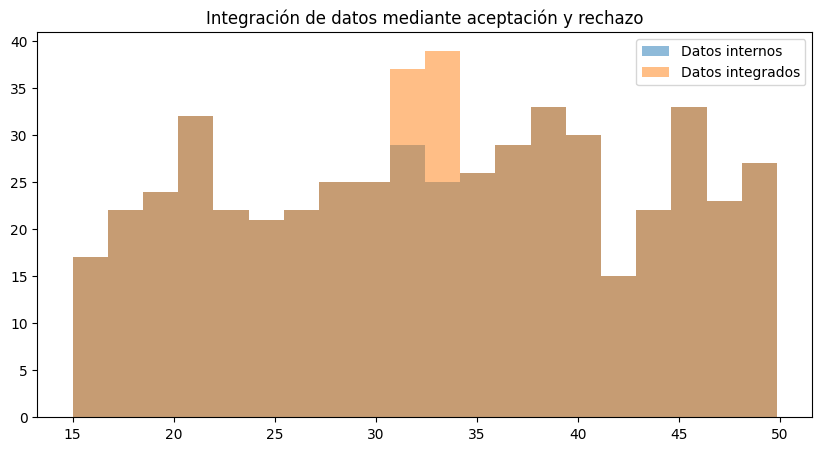

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(LDAo, bins=20, alpha=0.5, label="Datos internos")

plt.hist(LDAint3, bins=20, alpha=0.5, label="Datos integrados")

plt.legend()

plt.title("Integración de datos mediante aceptación y rechazo")

plt.show()

El gráfico permite comparar la distribución de los datos internos originales con la distribución obtenida después del proceso de integración. Se observa que ambas distribuciones mantienen una forma similar, lo que indica que el método de aceptación y rechazo preserva las características estadísticas de la base de datos.